# Projeto Semantix: Análise e Classificação de Tumores de Mama
---
* **Dissertação sobre o Problema:**
O diagnóstico precoce do câncer de mama é um dos maiores desafios da medicina moderna. A análise de biópsias exige tempo e recursos de patologistas altamente especializados. O atraso ou erro no diagnóstico tem custos altíssimos: falsos negativos colocam a vida da paciente em risco imediato, enquanto falsos positivos causam traumas psicológicos e exames invasivos desnecessários. O uso de Machine Learning para atuar como uma "segunda opinião automatizada" pode acelerar a triagem e aumentar a precisão clínica.

* **Fonte de Dados:**
Utilizaremos a base pública *Breast Cancer Wisconsin Diagnostic Database*, fornecida pela UCI Machine Learning Repository. Ela contém características computadas a partir de imagens digitalizadas de biópsias (FNA) de massas mamárias.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.datasets import load_breast_cancer
from sklearn.tree import plot_tree, DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

cancer_data = load_breast_cancer()
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target #0=maligno, 1=benigno
print(df.info()) #visão geral, sem variáveis categóricas

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [2]:
missing = df.isnull().sum()
percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({'Missing': missing,
                              'Percent (%)': percent}).sort_values(by='Missing',ascending=False)
print(missing_table[missing_table['Missing'] > 0]) #sem valores faltando

Empty DataFrame
Columns: [Missing, Percent (%)]
Index: []


In [3]:
df_copy = df.copy() #não modificar dados
df_const = add_constant(df_copy) #simula intercepto
vif_df = pd.DataFrame()
vif_df["Variável"] = df_const.columns
vif_df["VIF"] = [variance_inflation_factor(df_const.values, i) for i in range(df_const.shape[1])]
print(vif_df[vif_df["Variável"] != 'const'].sort_values(by="VIF",
                                                        ascending=False).reset_index(drop=True))

                   Variável          VIF
0               mean radius  3817.259795
1            mean perimeter  3792.697001
2              worst radius   815.945630
3           worst perimeter   405.150023
4                 mean area   348.115385
5                worst area   343.494355
6              radius error    75.737325
7            mean concavity    71.002747
8           perimeter error    70.398925
9       mean concave points    60.172431
10         mean compactness    51.445960
11               area error    41.196467
12        worst compactness    36.984867
13     worst concave points    36.781339
14          worst concavity    32.090394
15  worst fractal dimension    18.975850
16            worst texture    18.606605
17          concavity error    15.914022
18   mean fractal dimension    15.756978
19        compactness error    15.366350
20             mean texture    11.891280
21     concave points error    11.601253
22         worst smoothness    10.925968
23  fractal dime

## Análise de Multicolinearidade (*VIF - Variance Inflation Factor*)

* O teste *VIF* mede o quanto a variância de uma variável independente é inflada devido à correlação com outras variáveis, valores de *VIF* acima de 10 já indicam alta multicolinearidade.

* *Valores Extremos:*
Na base, encontramos alguns valores extremos, como mean radius (3817.25) e mean perimeter (3792.69), isso é porque o perímetro e a área de um núcleo celular são derivados matematicamente do seu raio, as três variáveis entregam a mesma informação sobre o tamanho do tumor. O mesmo padrão se repete com as métricas de "worst" e "error".

* A alta multicolinearidade prejudicaria modelos *lineares/SVM* sem tratamento manual, justificando o uso de *XGBoost*, que lida com variáveis redundantes nativamente em cada corte de árvore.

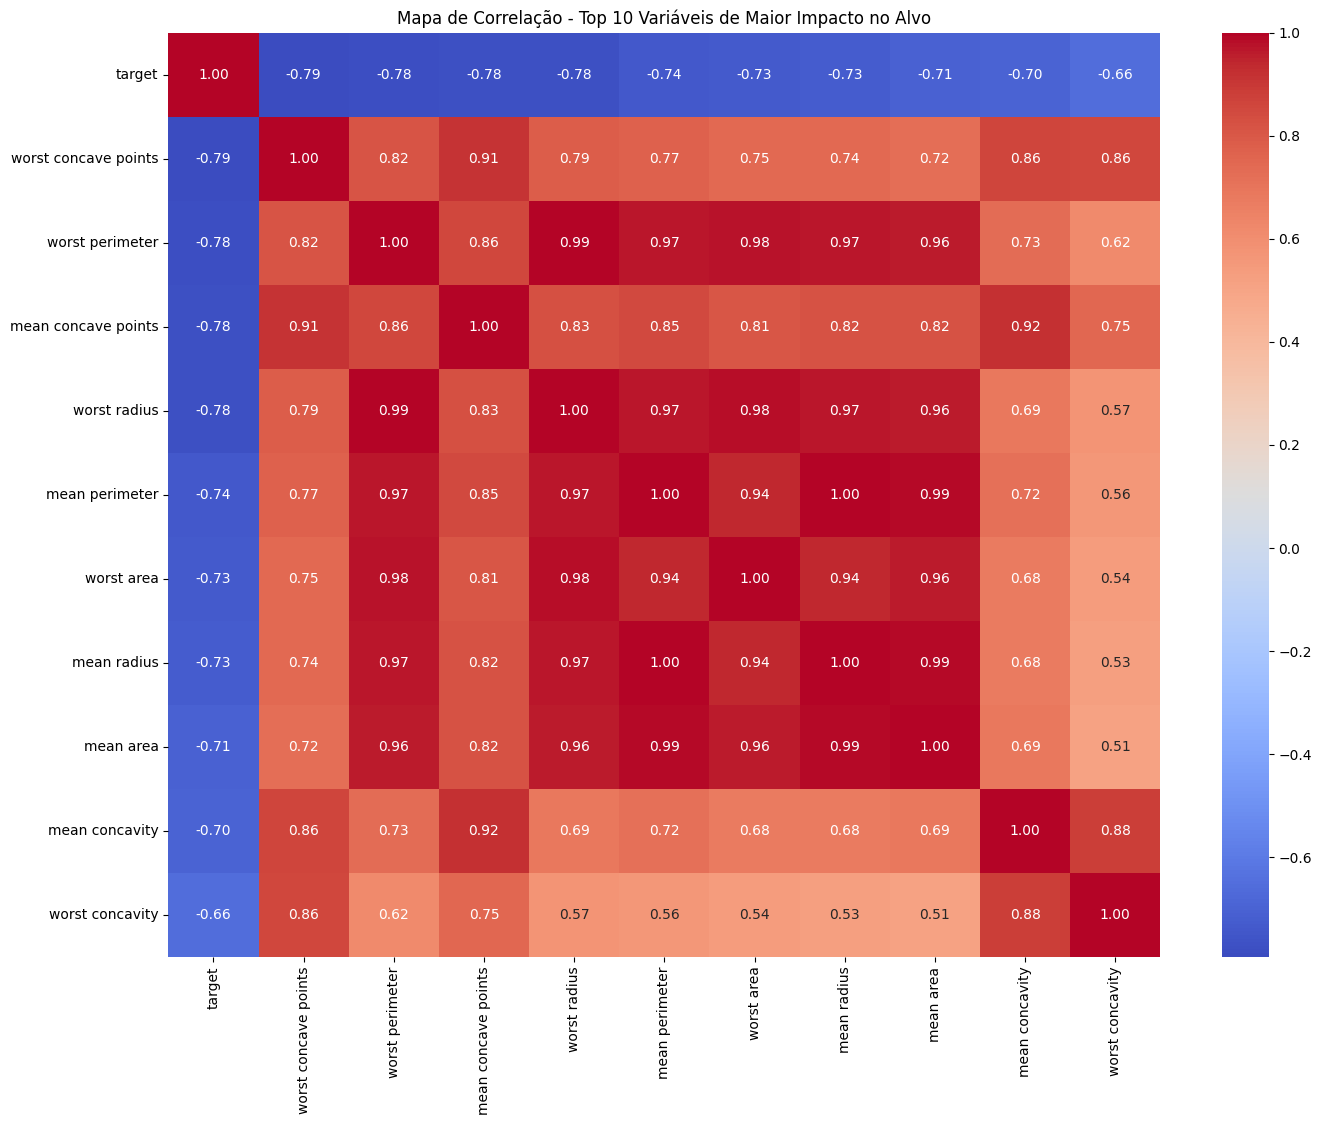

In [4]:
#pegando só as 10 variáveis com maior correlação com o alvo para não ficar ilegível
matriz_corr = df.corr()
top_features = matriz_corr['target'].abs().sort_values(ascending=False).head(11).index.tolist()
plt.figure(figsize=(16, 12))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mapa de Correlação - Top 10 Variáveis de Maior Impacto no Alvo")
plt.show()

In [5]:
print(df.describe())

       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

> Observando os valores mínimos, não há valores negativos ou zerados onde não deveriam existir (como um raio de tumor negativo).
> A grande variação nas escalas e desvios padrões, reforçam escolha de *XGBoost* que não é sensível a outliers e escalas

### Análise de Distribuição e Outliers
Para compreender a morfologia dos tumores, iniciamos avaliando a dispersão das variáveis macroscópicas do nosso *dataset*.

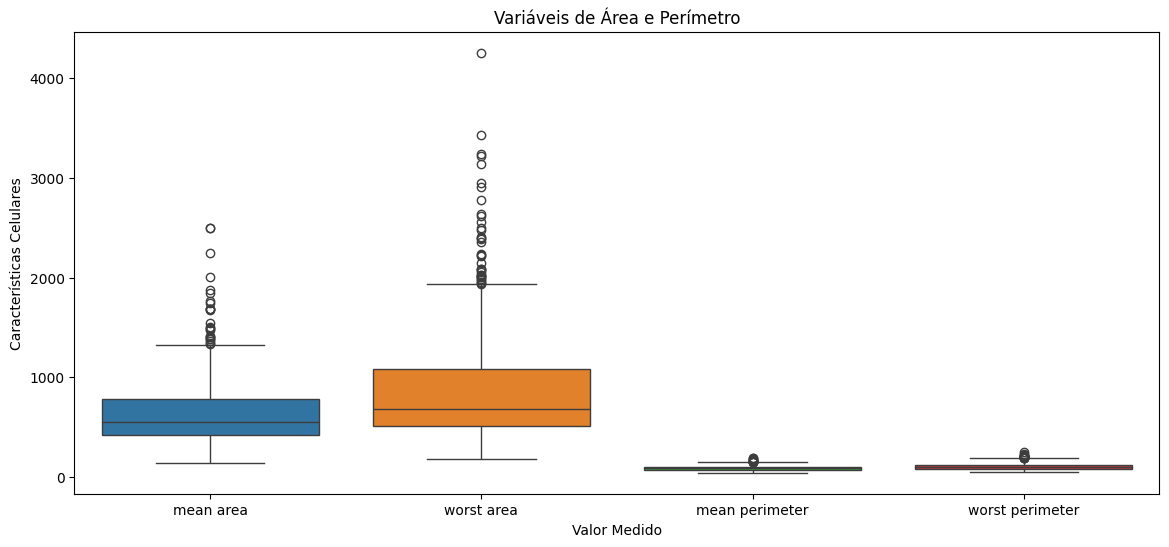

In [6]:
colunas_tamanho = ['mean area', 'worst area', 'mean perimeter', 'worst perimeter']
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[colunas_tamanho])
plt.title("Variáveis de Área e Perímetro")
plt.xlabel("Valor Medido")
plt.ylabel("Características Celulares")
plt.show()

> **Insight da Distribuição:**
> Forte presença de *outliers* nas caudas de todas as quatro variáveis, crescimento anômalo de tumores severos.
>
> Pela escolha de algoritmos baseados em árvores, foi decidido *não aplicar técnicas de remoção ou capping* nestes *outliers*.

---

### Análise Bivariada:
Para entender a interação entre elas, cruzamos uma medida de tamanho (`mean radius`) com uma medida de irregularidade da superfície celular (`mean texture`), mapeando os diagnósticos sobrepostos.

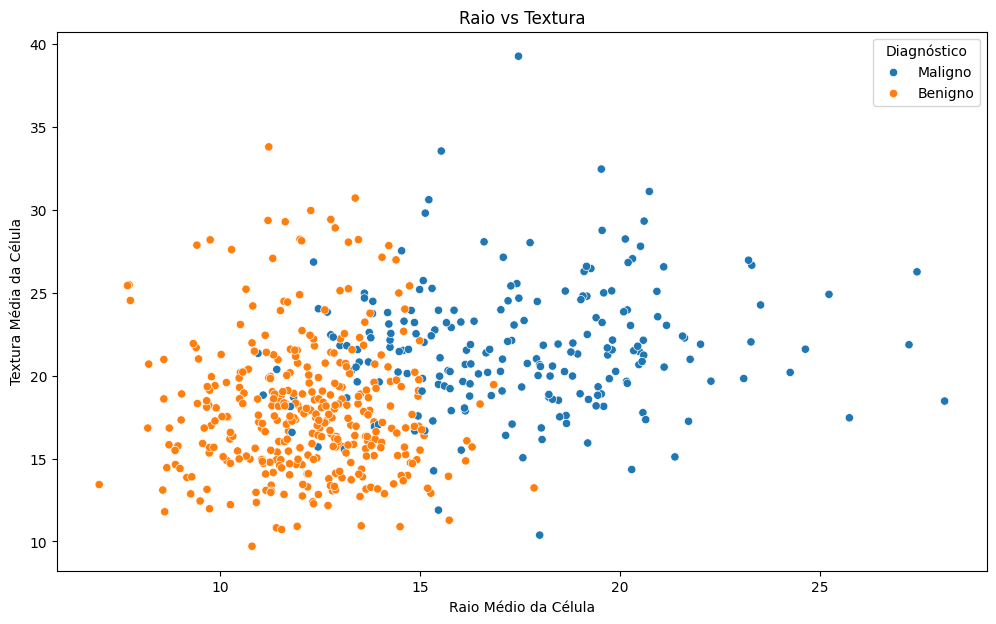

In [7]:
df_plot = df.copy()
df_plot['Diagnóstico'] = df_plot['target'].map({0: 'Maligno', 1: 'Benigno'})
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_plot, x='mean radius', y='mean texture', hue='Diagnóstico')
plt.title("Raio vs Textura")
plt.xlabel("Raio Médio da Célula")
plt.ylabel("Textura Média da Célula")
plt.show()

> **Insight Bivariado:**
> Nítida separação entre as classes, células maiores e com textura mais áspera concentram-se em tumores **Malignos** e células menores e de mais suaves formam o aglomerado de diagnósticos **Benignos**.

In [8]:
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#árvore de Decisão como modelo baseline
arvore_decisao = Pipeline([('smote', SMOTE(random_state=42)),
                           ('model', DecisionTreeClassifier(random_state=42, max_depth=3))])
arvore_decisao.fit(X_train, y_train)

pred_treino = arvore_decisao.predict(X_train)
acuracia_treino = accuracy_score(y_train, pred_treino)
print(f"\nAcurácia do modelo base nos dados de treino: {acuracia_treino * 100:.2f}%\n")
print(classification_report(y_train, pred_treino))



Acurácia do modelo base nos dados de treino: 96.92%

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       169
           1       0.98      0.97      0.98       286

    accuracy                           0.97       455
   macro avg       0.97      0.97      0.97       455
weighted avg       0.97      0.97      0.97       455



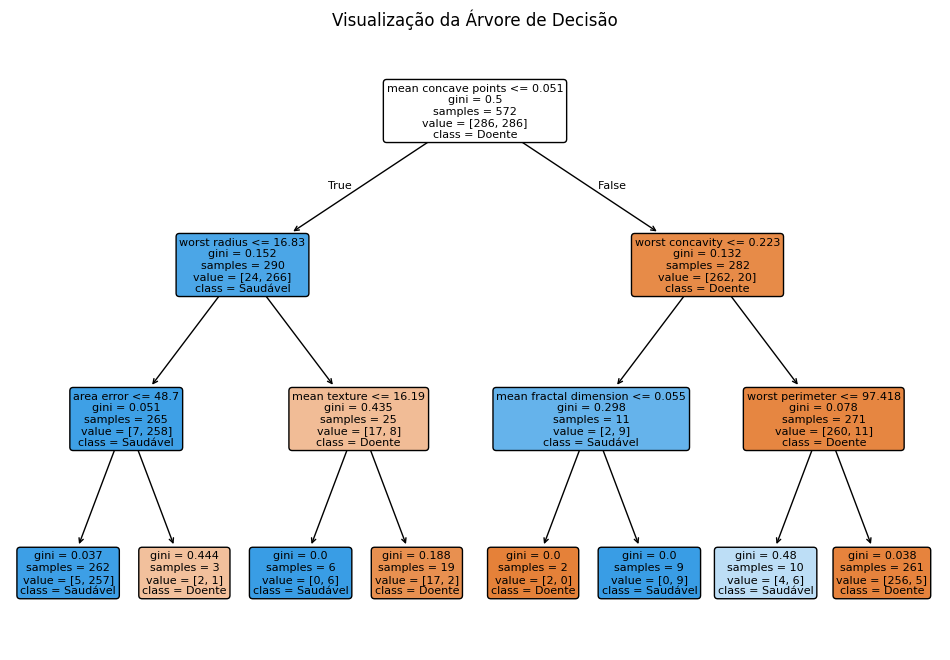

In [9]:
class_names = ['Doente', 'Saudável']
plt.figure(figsize=(12, 8))
plot_tree(arvore_decisao.named_steps['model'], filled=True, rounded=True,
          feature_names=X_train.columns, class_names=class_names, fontsize=8)
plt.title("Visualização da Árvore de Decisão")
plt.show()

Acurácias do modelo base obtidas em cada uma das 5 rodadas: [93.41 87.91 91.21 89.01 94.51]%
Acurácia média: 91.21%

Acurácia do modelo base nos dados de teste: 97.37%

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



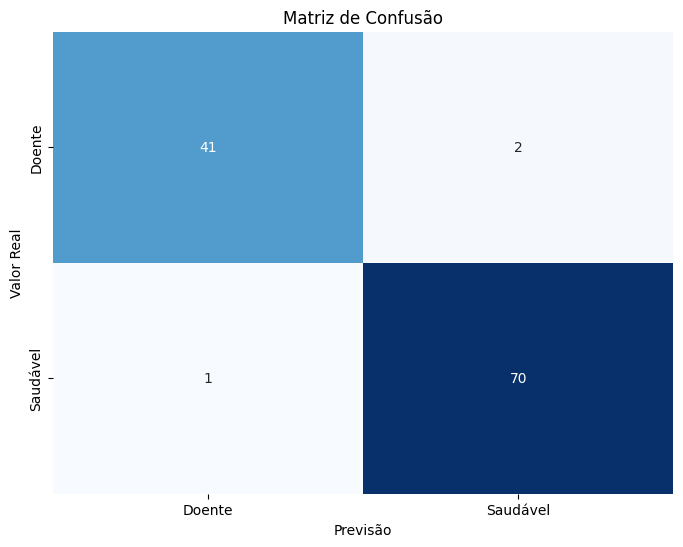

In [10]:
#validação cruzada
scores = cross_val_score(arvore_decisao, X_train, y_train.values.ravel(), cv=5)
print(f"Acurácias do modelo base obtidas em cada uma das 5 rodadas: {np.round(scores * 100, 2)}%")
print(f"Acurácia média: {scores.mean() * 100:.2f}%")
#modelo generaliza

pred_teste = arvore_decisao.predict(X_test)
acuracia_teste = accuracy_score(y_test, pred_teste)
print(f"\nAcurácia do modelo base nos dados de teste: {acuracia_teste * 100:.2f}%\n")
print(classification_report(y_test, pred_teste))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, pred_teste), annot=True, fmt='d', cmap='Blues', cbar=False,
				xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão')
plt.ylabel('Valor Real')
plt.xlabel('Previsão')
plt.show()

In [11]:
df_importancia = pd.DataFrame({'Feature': X_train.columns, 'Importancia': arvore_decisao.named_steps['model'].feature_importances_})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).reset_index(drop=True)
df_importancia['Importancia (%)'] = (df_importancia['Importancia'] / df_importancia['Importancia'].sum() * 100).round(2)
print(df_importancia)

                    Feature  Importancia  Importancia (%)
0       mean concave points     0.797948            79.79
1              worst radius     0.076041             7.60
2           worst concavity     0.049805             4.98
3              mean texture     0.028445             2.84
4           worst perimeter     0.025319             2.53
5    mean fractal dimension     0.012751             1.28
6                area error     0.009692             0.97
7               mean radius     0.000000             0.00
8   fractal dimension error     0.000000             0.00
9             worst texture     0.000000             0.00
10               worst area     0.000000             0.00
11     concave points error     0.000000             0.00
12         worst smoothness     0.000000             0.00
13        worst compactness     0.000000             0.00
14     worst concave points     0.000000             0.00
15           worst symmetry     0.000000             0.00
16           s

> **Análise Clínica do Baseline**
> Apesar de *97% de acurácia*, o modelo apresenta *5% de Falsos Negativos* e uma dependência perigosa de ***~80%** em uma única variável* (`mean concave points`), apenas 7 variáveis influenciam o modelo.

Melhores Hiperparâmetros:
{'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Acurácia do modelo base reduzido nos dados de teste: 95.61%

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



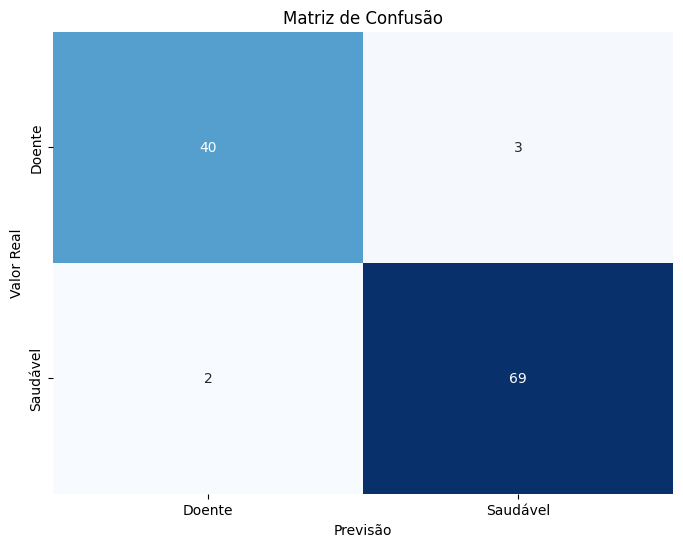

In [12]:
features_reduzidas = ['mean concave points', 'worst radius', 'worst concavity', 'mean texture', 'worst perimeter', 'mean fractal dimension', 'area error']
X_treino_red = X_train[features_reduzidas]
X_teste_red = X_test[features_reduzidas]

parametros_grid = {'model__criterion': ['gini', 'entropy'], 'model__max_depth': [3, 4, 5],
                   'model__min_samples_split': [2, 5, 10], 'model__min_samples_leaf': [1, 5, 10]}

arvore_decisao_red = Pipeline([('smote', SMOTE(random_state=0)),
                               ('model', DecisionTreeClassifier(random_state=0))])

grid_search = GridSearchCV(arvore_decisao_red, param_grid=parametros_grid,
                           cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_treino_red, y_train)
melhor_arvore_red = grid_search.best_estimator_

print(f"Melhores Hiperparâmetros:\n{grid_search.best_params_}")
pred_red = melhor_arvore_red.predict(X_teste_red)
acuracia_red_teste = accuracy_score(y_test, pred_red)
print(f"Acurácia do modelo base reduzido nos dados de teste: {acuracia_red_teste * 100:.2f}%\n")
print(classification_report(y_test, pred_red))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, pred_red), annot=True, fmt='d', cmap='Blues', cbar=False,
				xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão')
plt.ylabel('Valor Real')
plt.xlabel('Previsão')
plt.show()

> O modelo reduzido eliminou o ruído e evitou o *overfitting* (mantendo **95.6% de acurácia**), mas recall de casos malignos **caiu para 93%**, em um cenário médico 2% de casos negativos faz bastante diferença.

   Previsão  Probabilidade Doença
0         1             99.010002
1         0              0.110000
2         0              0.150000
3         1             99.330002
4         1             99.919998


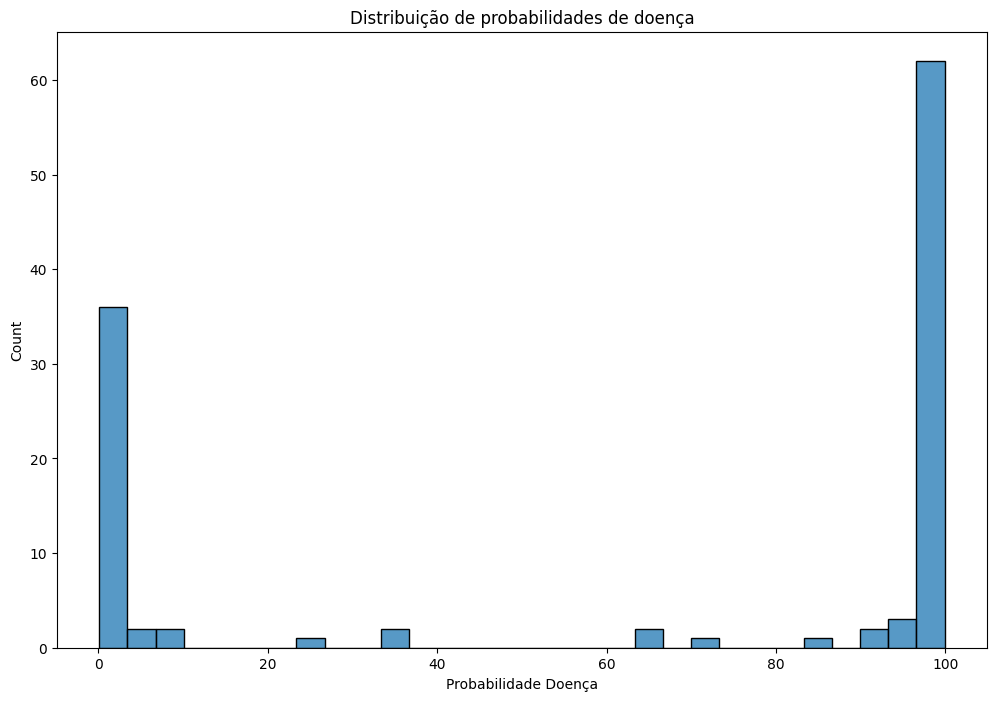

In [13]:
parametros_random = {'model__learning_rate': [0.01, 0.05, 0.1, 0.2], 'model__max_depth': [3, 4, 5, 6],
                     'model__n_estimators': [50, 100, 200, 300], 'model__subsample': [0.8, 0.9, 1.0], 'model__colsample_bytree': [0.8, 0.9, 1.0]}

xgb = Pipeline([('smote', SMOTE(random_state=0)),
                ('model', XGBClassifier(random_state=0))])

random_search = RandomizedSearchCV(xgb, param_distributions=parametros_random, n_iter=20,
                                   cv=5, scoring='accuracy', n_jobs=-1,  random_state=42)

random_search.fit(X_treino_red, y_train)
modelo_xgb = random_search.best_estimator_

previsoes = modelo_xgb.predict(X_teste_red)
prob = modelo_xgb.predict_proba(X_teste_red)
df_resultados = pd.DataFrame({'Previsão': previsoes,
                              'Probabilidade Doença': np.round(prob[:, 1] * 100, decimals= 2)})
print(df_resultados.head())

plt.figure(figsize=(12, 8))
sns.histplot(df_resultados['Probabilidade Doença'], bins=30)
plt.title('Distribuição de probabilidades de doença')
plt.show()

>Modelo atinge ~99% de certeza nos diagnósticos positivos,
> se a chance cair na faixa de 20% a 70%, o sistema poderia acionar uma revisão médica manual


Acurácia do Modelo XGBoost: 98.25%

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



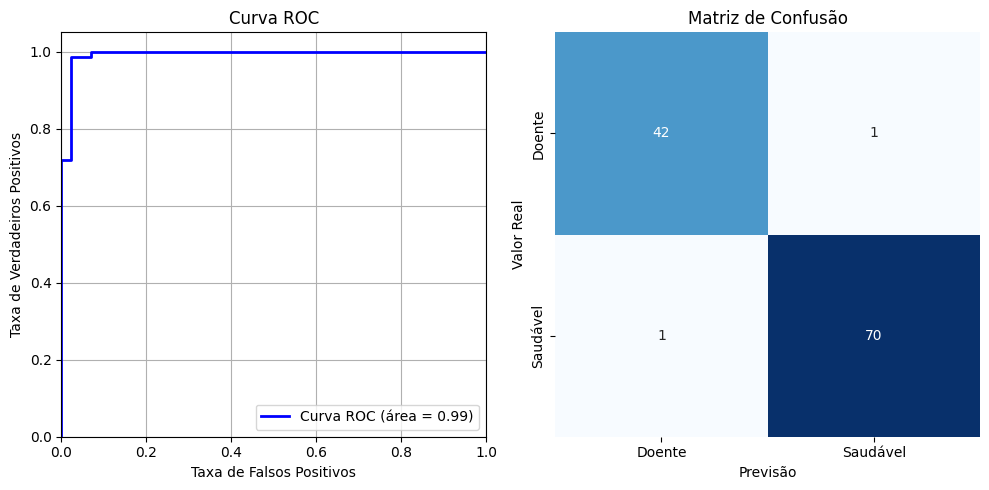

In [14]:
acuracia = accuracy_score(y_test, previsoes)
print(f"\nAcurácia do Modelo XGBoost: {acuracia * 100:.2f}%\n")
print(classification_report(y_test, previsoes))

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
if len(prob.shape) > 1:
    prob = prob[:, 1]
#fpr(taxa falsos positivos) tpr(taxa de verdadeiros positivos) threshold(cutoff de % de certeza)
fpr, tpr, thresholds = roc_curve(y_test, prob)
auc_score = roc_auc_score(y_test, prob)
axes[0].plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (área = {auc_score:.2f})')
# linha de referência do chute aleatório
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('Taxa de Falsos Positivos')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos')
axes[0].set_title('Curva ROC')
axes[0].legend(loc="lower right")
axes[0].grid(True)

sns.heatmap(confusion_matrix(y_test, previsoes), annot=True, fmt='d', cmap='Blues', cbar=False,
				xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Matriz de Confusão')
axes[1].set_ylabel('Valor Real')
axes[1].set_xlabel('Previsão')

plt.tight_layout()
plt.show()

> **Desempenho do Modelo, Curva ROC e o AUC**
> ---
> ##### XGBoost atingiu **98% de acurácia global** e recuperou a segurança clínica elevando o **Recall de tumores malignos para 98%**.
> A Curva ROC avalia o quão bem o algoritmo consegue separar os pacientes doentes dos saudáveis sem se confundir.
>
> * **A linha vermelha tracejada** representa um chute cego (50% de chance).
> * **A linha azul** representa a inteligência do nosso modelo, quanto mais ela se aproxima do teto no canto superior esquerdo, melhor é o sistema.
>
> Nosso modelo obteve um **AUC (Área Sob a Curva) de 0.99**, o que significa que se sortearmos um paciente com tumor maligno e um paciente saudável, o modelo tem **99% de chance de distinguir corretamente o paciente doente do saudável**, entregando um sistema automatizado e pronto para triagem médica.

In [15]:
importancias = modelo_xgb.named_steps['model'].feature_importances_
df_importancia = pd.DataFrame({'Feature': X_teste_red.columns, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).reset_index(drop=True)
df_importancia['Importancia (%)'] = (df_importancia['Importancia'] / df_importancia['Importancia'].sum() * 100).round(2)
print(df_importancia)

                  Feature  Importancia  Importancia (%)
0     mean concave points     0.441882        44.189999
1            worst radius     0.199761        19.980000
2         worst perimeter     0.159793        15.980000
3            mean texture     0.064964         6.500000
4         worst concavity     0.059029         5.900000
5              area error     0.057404         5.740000
6  mean fractal dimension     0.017167         1.720000


> **Distribuição do Peso Clínico**
> O problema de hiperdependência foi resolvido. A variável `mean concave points` ainda é o principal indicador (43.8%), mas agora a responsabilidade preditiva está distribuída de forma muito mais saudável com variáveis de dimensão, como o `worst radius` (18.7%) e o `worst perimeter` (17.9%).

---

## Conclusão do Projeto

1. **Análise Exploratória (EDA):** Foi decidido que algoritmos baseados em árvores seriam ideais, dada a não-linearidade e a presença de anomalias que representam o crescimento tumoral real.
2. **Modelagem Baseline:** Iniciamos com uma Árvore de Decisão simples, que alcançou 97% de acurácia global, mas revelou vulnerabilidades clínicas: uma taxa de 5% de Falsos Negativos e uma perigosa dependência de quase 80% em uma única variável.
3. **Otimização e Ensemble:** Para garantir a segurança médica exigida, implementamos um algoritmo de *Gradient Boosting*.
4. **Resultado Final:** O modelo definitivo atingiu **98% de Acurácia**, uma curva ROC quase perfeita (**AUC de 0.99**) e, mais importante, elevou o **Recall da classe maligna para 98%**.

**Veredito:** O modelo final provou ser não apenas estatisticamente preciso, mas clinicamente seguro. Ele distribui os pesos das decisões entre múltiplas medições celulares e minimiza as chances de liberar pacientes doentes como saudáveis, validando sua utilidade como uma poderosa ferramenta de suporte à decisão médica em hospitais e clínicas.